In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,MinMaxScaler 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector

In [2]:
df=pd.read_csv("loan.csv")
df.head(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [3]:
mn_la=np.mean(df["LoanAmount"])
mn_ai=np.mean(df["ApplicantIncome"])
mn_ci=np.mean(df["CoapplicantIncome"])
print(mn_ai)
print(mn_ci)
print(mn_la)

5403.459283387622
1621.2457980271008
146.41216216216216


In [4]:
df["Gender"].mode()

0    Male
Name: Gender, dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
is_null=df.isnull().sum()/df.shape[0]*100
is_null

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

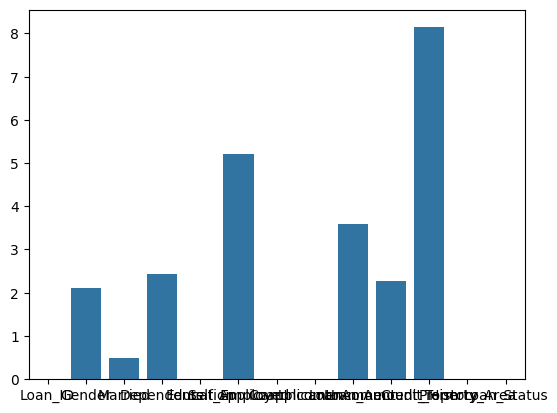

In [36]:
plt.Figure(figsize=[9,25])
sns.barplot(data=is_null)
plt.show()

In [8]:
#filling empty places with mode using scikit learn
si=SimpleImputer(strategy="most_frequent")
ar=si.fit_transform(df)
data=pd.DataFrame(ar,columns=df.columns)

In [9]:
data.head(8)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N


In [10]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [11]:
dfn=data[["Married","Gender","Self_Employed","Loan_Status","Education"]]

In [ ]:
ohe=OneHotEncoder(drop="first")
ar=ohe.fit_transform(dfn).toarray()
n=pd.DataFrame(ar,columns=["Married_N","Gender_N","Self_Employed_N","Loan_Status_N","Education_N"])
data[["Married_N","Gender_N","Self_Employed_N","Loan_Status_N","Education_N"]]=n
data.drop(columns=["Married","Gender","Self_Employed","Loan_Status","Education"],inplace=True)

In [13]:
le=LabelEncoder()
data["Property_Area"]=le.fit_transform(data["Property_Area"])

In [14]:
data["Loan_ID"]=le.fit_transform(data["Loan_ID"])

In [15]:
data["Dependents"]=le.fit_transform(data["Dependents"])

C:\Users\mitad\AppData\Local\Temp\ipykernel_18488\3733718079.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["CoapplicantIncome"])


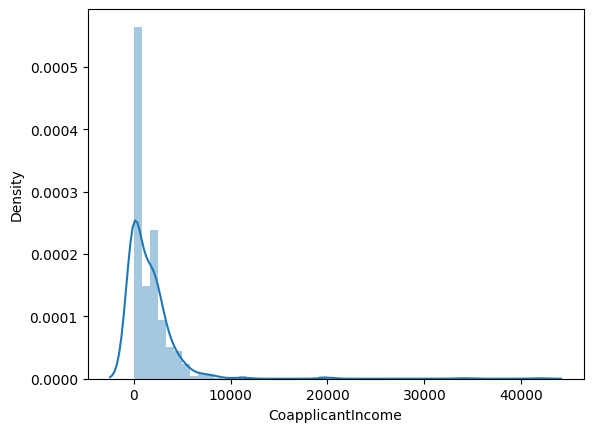

In [16]:
sns.distplot(data["CoapplicantIncome"])
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18488\3505424377.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["CoapplicantIncome"])


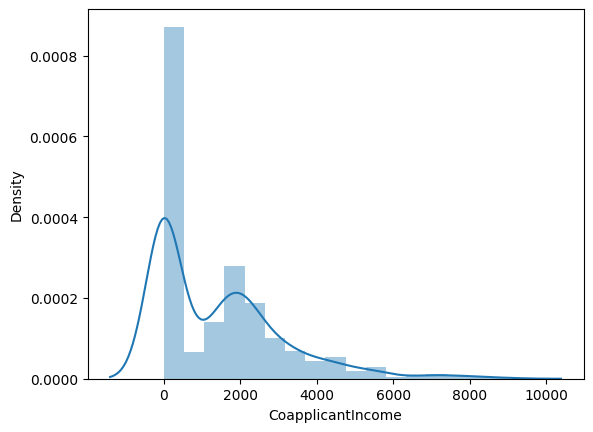

In [17]:
Max=np.mean(data["CoapplicantIncome"])+(3*np.std(data["CoapplicantIncome"]))
data=data[data["CoapplicantIncome"]<=Max]
sns.distplot(data["CoapplicantIncome"])
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18488\2280944538.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["ApplicantIncome"])


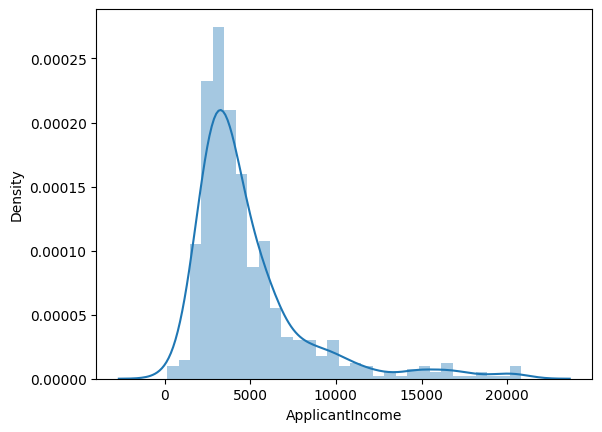

In [18]:
Max=np.mean(data["ApplicantIncome"])+(3*np.std(data["ApplicantIncome"]))
data=data[data["ApplicantIncome"]<=Max]
sns.distplot(data["ApplicantIncome"])
plt.show()

C:\Users\mitad\AppData\Local\Temp\ipykernel_18488\4176192800.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["LoanAmount"])


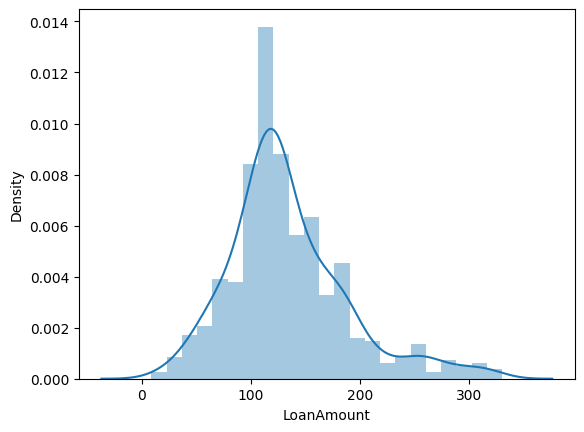

In [19]:
Max=np.mean(data["LoanAmount"])+(3*np.std(data["LoanAmount"]))
data=data[data["LoanAmount"]<=Max]
sns.distplot(data["LoanAmount"])
plt.show()

In [20]:
data["Loan_ID"].drop_duplicates(inplace=True)

In [21]:
ms=MinMaxScaler()
ar=ms.fit_transform(data)
data=pd.DataFrame(ar,columns=['Loan_ID','Dependents','ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History','Property_Area','Married_N','Gender_N','Self_Employed_N','Loan_Status_N','Education_N'])

In [22]:
x=data[['Loan_ID','Dependents','ApplicantIncome','CoapplicantIncome','Loan_Amount_Term','Credit_History','Property_Area','Married_N','Gender_N','Self_Employed_N','Loan_Status_N','Education_N']]
y=data["LoanAmount"]

In [23]:
lr=LinearRegression()

In [24]:
sf=SequentialFeatureSelector(lr,k_features=6,forward=True)
sf.fit(x,y)

SequentialFeatureSelector(estimator=LinearRegression(), k_features=(6, 6),
                          scoring='r2')

In [25]:
sf.feature_names

['Loan_ID',
 'Dependents',
 'ApplicantIncome',
 'CoapplicantIncome',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Married_N',
 'Gender_N',
 'Self_Employed_N',
 'Loan_Status_N',
 'Education_N']

In [26]:
sf.k_feature_names_

('Dependents',
 'ApplicantIncome',
 'CoapplicantIncome',
 'Loan_Amount_Term',
 'Loan_Status_N',
 'Education_N')

In [27]:
sf.k_score_

np.float64(0.3029680878933981)

In [28]:
data=data[['Dependents',
 'ApplicantIncome',
 'CoapplicantIncome',
 'Loan_Amount_Term',
 'Loan_Status_N',
 'Education_N',"LoanAmount"]]
data["LoanAmount"]=y

In [29]:
x=data[['Dependents','ApplicantIncome','CoapplicantIncome','Loan_Amount_Term','Loan_Status_N','Education_N']]
y=data["LoanAmount"]

In [30]:
data.to_csv('data.csv', index=False)

In [37]:
x_train,y_train,x_test,y_test=train_test_split(x,y,test_size=0.20)

In [38]:
data

,Dependents,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Loan_Status_N,Education_N,LoanAmount
0,0.000000,0.277770,0.000000,0.743590,1.0,0.0,0.345794
1,0.333333,0.216065,0.167929,0.743590,0.0,0.0,0.370717
2,0.000000,0.138909,0.000000,0.743590,1.0,0.0,0.177570
3,0.000000,0.118585,0.262584,0.743590,1.0,1.0,0.345794
4,0.000000,0.285129,0.000000,0.743590,1.0,0.0,0.411215
...,...,...,...,...,...,...,...
582,0.000000,0.134035,0.000000,0.743590,1.0,0.0,0.193146
583,1.000000,0.192816,0.000000,0.358974,1.0,0.0,0.096573
584,0.333333,0.386119,0.026726,0.743590,1.0,0.0,0.760125
585,0.666667,0.362285,0.000000,0.743590,1.0,0.0,0.554517
